# Expectation and Variance of a Continuous Random Variable

Let $X$ be a continuous random variable with PDF $f(x)$.

## Expectation (Mean) — First-Order Statistical Moment

$$E[X] = \int_{-\infty}^{\infty} x \, f(x) \, dx$$

## Variance — Second-Order Statistical Moment

$$\sigma^2 = E[(X - \mu)^2] = \int_{-\infty}^{\infty} (x - \mu)^2 \, f(x) \, dx$$

**Alternative (computational) formula:**

$$\sigma^2 = E[X^2] - \mu^2 \qquad \text{where} \quad E[X^2] = \int_{-\infty}^{\infty} x^2 \, f(x) \, dx$$

**Standard deviation:**

$$\sigma = \sqrt{\text{Variance}}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.stats import norm, uniform, expon, beta
from scipy.integrate import quad

plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   '#f8f9fa',
    'axes.grid':        True,
    'grid.alpha':       0.35,
    'font.size':        11,
})

## Expectation E[X]

$$E[X] = \int_{-\infty}^{\infty} x \, f(x) \, dx$$

$E[X]$ is the **weighted average** of all possible values, where the weight at each point is the PDF value $f(x)$ — a continuous analogue of $E[X] = \sum x_i \, P(X = x_i)$.

Below we compute $E[X]$ numerically for $X \sim \mathcal{N}(170, 10^2)$ and verify against the analytic result ($\mu = 170$).

In [2]:
mu_true, sigma_true = 170.0, 10.0
dist = norm(loc=mu_true, scale=sigma_true)
lo, hi = mu_true - 8*sigma_true, mu_true + 8*sigma_true

# E[X] = ∫ x·f(x) dx
E_X, _ = quad(lambda x: x * dist.pdf(x), lo, hi)

print(f"Numerical E[X] = ∫ x·f(x)dx = {E_X:.6f}")
print(f"Analytic  E[X] = μ           = {mu_true:.6f}")
print(f"Match: {np.isclose(E_X, mu_true, rtol=1e-6)}")

Numerical E[X] = ∫ x·f(x)dx = 170.000000
Analytic  E[X] = μ           = 170.000000
Match: True


Distribution                 E[X] numerical  E[X] analytic
──────────────────────────────────────────────────────────
Uniform(2, 8)                      5.000000       5.000000
Exponential(λ=1.5)                 0.666613       0.666667
Normal(5, σ²=4)                    4.999683       5.000000
Beta(α=2, β=5)                     0.285714       0.285714


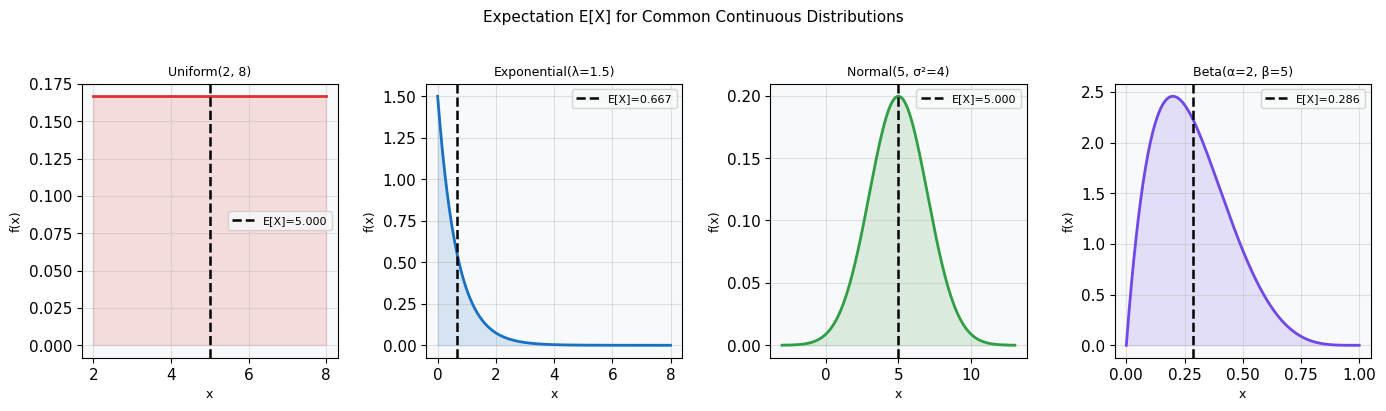

In [3]:
# --- E[X] for common continuous distributions ---
configs_ex = [
    {'dist': uniform(loc=2, scale=6),  'lo': 2,   'hi': 8,   'label': 'Uniform(2, 8)',       'color': '#e03131', 'analytic': 5.0},
    {'dist': expon(scale=1/1.5),       'lo': 0,   'hi': 8,   'label': 'Exponential(λ=1.5)',  'color': '#1971c2', 'analytic': 1/1.5},
    {'dist': norm(loc=5, scale=2),     'lo': -3,  'hi': 13,  'label': 'Normal(5, σ²=4)',     'color': '#2f9e44', 'analytic': 5.0},
    {'dist': beta(2, 5),               'lo': 0,   'hi': 1,   'label': 'Beta(α=2, β=5)',      'color': '#7048e8', 'analytic': 2/(2+5)},
]

fig, axes = plt.subplots(1, 4, figsize=(14, 4))
print(f"{'Distribution':<26} {'E[X] numerical':>16} {'E[X] analytic':>14}")
print('─' * 58)

for ax, cfg in zip(axes, configs_ex):
    x = np.linspace(cfg['lo'], cfg['hi'], 500)
    y = cfg['dist'].pdf(x)
    ex_num, _ = quad(lambda t: t * cfg['dist'].pdf(t), cfg['lo'], cfg['hi'])

    ax.plot(x, y, color=cfg['color'], lw=2)
    ax.fill_between(x, 0, y, alpha=0.15, color=cfg['color'])
    ax.axvline(ex_num, color='black', lw=1.8, ls='--', label=f'E[X]={ex_num:.3f}')
    ax.set_title(cfg['label'], fontsize=9)
    ax.set_xlabel('x', fontsize=9)
    ax.set_ylabel('f(x)', fontsize=9)
    ax.legend(fontsize=8)

    print(f"{cfg['label']:<26} {ex_num:>16.6f} {cfg['analytic']:>14.6f}")

plt.suptitle('Expectation E[X] for Common Continuous Distributions', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

## Variance σ²

$$\sigma^2 = E[(X-\mu)^2] = \int_{-\infty}^{\infty}(x-\mu)^2 f(x)\,dx$$

Using $X \sim \mathcal{N}(\mu=170, \sigma_{\text{true}}=10)$, we compute both methods numerically and compare against the analytic result ($\sigma^2 = 100$).

In [4]:
mu, sigma_true = 170.0, 10.0
dist = norm(loc=mu, scale=sigma_true)

# Integration bounds: avoid numerical issues with infinite bounds far from centre
lo, hi = mu - 8*sigma_true, mu + 8*sigma_true

# E[X] = mean
E_X, _ = quad(lambda x: x * dist.pdf(x), lo, hi)

# Method 1: σ² = ∫(x−μ)² f(x) dx
var_direct, _ = quad(lambda x: (x - E_X)**2 * dist.pdf(x), lo, hi)

# Method 2: σ² = E[X²] − μ²
E_X2, _  = quad(lambda x: x**2 * dist.pdf(x), lo, hi)
var_alt   = E_X2 - E_X**2

print(f"E[X]             = {E_X:.4f}  (analytic: {mu})")
print()
print(f"Method 1 — ∫(x−μ)²f(x)dx:")
print(f"  σ²             = {var_direct:.6f}")
print(f"  σ              = {np.sqrt(var_direct):.6f}")
print()
print(f"Method 2 — E[X²] − μ²:")
print(f"  E[X²]          = {E_X2:.6f}")
print(f"  μ²             = {E_X**2:.6f}")
print(f"  σ²             = {var_alt:.6f}")
print()
print(f"Analytic σ²      = {sigma_true**2:.1f}")
print(f"Both methods agree: {np.isclose(var_direct, var_alt, rtol=1e-6)}")

E[X]             = 170.0000  (analytic: 170.0)

Method 1 — ∫(x−μ)²f(x)dx:
  σ²             = 100.000000
  σ              = 10.000000

Method 2 — E[X²] − μ²:
  E[X²]          = 29000.000000
  μ²             = 28900.000000
  σ²             = 100.000000

Analytic σ²      = 100.0
Both methods agree: True


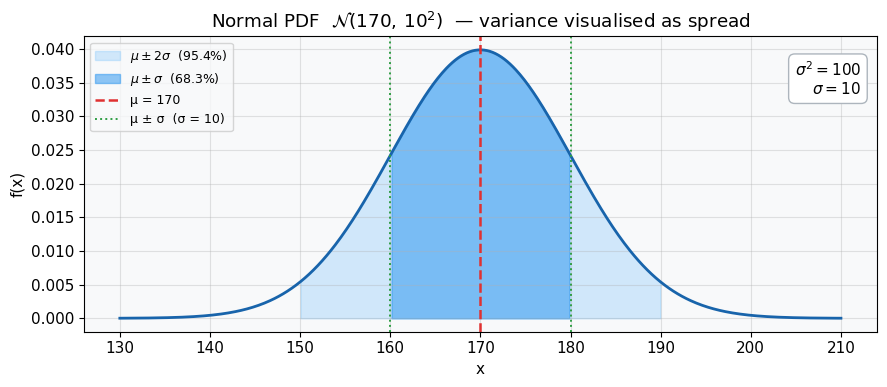

In [5]:
# --- PDF with ±σ and ±2σ shading ---
x = np.linspace(mu - 4*sigma_true, mu + 4*sigma_true, 500)
y = dist.pdf(x)

fig, ax = plt.subplots(figsize=(9, 4))

# ±2σ band (outer, lighter)
mask2 = (x >= mu - 2*sigma_true) & (x <= mu + 2*sigma_true)
ax.fill_between(x, 0, y, where=mask2, color='#74c0fc', alpha=0.30,
                label=r'$\mu \pm 2\sigma$  (95.4%)')

# ±1σ band (inner, darker)
mask1 = (x >= mu - sigma_true) & (x <= mu + sigma_true)
ax.fill_between(x, 0, y, where=mask1, color='#339af0', alpha=0.55,
                label=r'$\mu \pm \sigma$  (68.3%)')

ax.plot(x, y, color='#1864ab', lw=2)
ax.axvline(mu, color='#e03131', lw=1.8, ls='--', label=f'μ = {mu:.0f}')
ax.axvline(mu - sigma_true, color='#2f9e44', lw=1.4, ls=':')
ax.axvline(mu + sigma_true, color='#2f9e44', lw=1.4, ls=':',
           label=f'μ ± σ  (σ = {sigma_true:.0f})')

ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title(r'Normal PDF  $\mathcal{N}(170,\,10^2)$  — variance visualised as spread')
ax.legend(fontsize=9)
# Annotate σ² value
ax.text(0.98, 0.92, f'$\\sigma^2 = {sigma_true**2:.0f}$\n$\\sigma = {sigma_true:.0f}$',
        transform=ax.transAxes, ha='right', va='top',
        bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#adb5bd'))
plt.tight_layout()
plt.show()

## Same Mean, Different Variance

Two distributions can share the same mean $\mu$ but differ entirely in **spread** ($\sigma^2$).  
Larger $\sigma^2$ → PDF is flatter and wider; smaller $\sigma^2$ → PDF is taller and narrower.

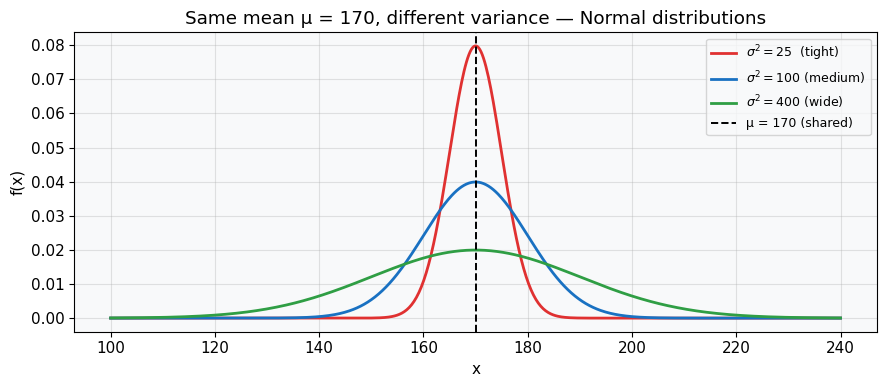

In [6]:
configs = [
    {'sigma': 5,  'color': '#e03131', 'label': r'$\sigma^2=25$  (tight)'},
    {'sigma': 10, 'color': '#1971c2', 'label': r'$\sigma^2=100$ (medium)'},
    {'sigma': 20, 'color': '#2f9e44', 'label': r'$\sigma^2=400$ (wide)'},
]

x = np.linspace(100, 240, 600)
fig, ax = plt.subplots(figsize=(9, 4))

for cfg in configs:
    d = norm(loc=170, scale=cfg['sigma'])
    ax.plot(x, d.pdf(x), color=cfg['color'], lw=2, label=cfg['label'])

ax.axvline(170, color='black', lw=1.4, ls='--', label='μ = 170 (shared)')
ax.set_xlabel('x')
ax.set_ylabel('f(x)')
ax.set_title('Same mean μ = 170, different variance — Normal distributions')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## Variance of Common Continuous Distributions

| Distribution | Parameters | $E[X]$ | $\text{Var}(X)$ |
|---|---|---|---|
| Uniform | $a, b$ | $\frac{a+b}{2}$ | $\frac{(b-a)^2}{12}$ |
| Exponential | $\lambda$ | $\frac{1}{\lambda}$ | $\frac{1}{\lambda^2}$ |
| Normal | $\mu, \sigma^2$ | $\mu$ | $\sigma^2$ |
| Beta | $\alpha, \beta$ | $\frac{\alpha}{\alpha+\beta}$ | $\frac{\alpha\beta}{(\alpha+\beta)^2(\alpha+\beta+1)}$ |

Distribution                     E[X]   Var(X) num  Var(X) analytic
────────────────────────────────────────────────────────────────────
Uniform(2, 8)                  5.0000     3.000000         3.000000
Exponential(λ=1.5)             0.6667     0.444444         0.444444
Normal(5, σ²=4)                5.0000     4.000000         4.000000
Beta(α=2, β=5)                 0.2857     0.025510         0.025510


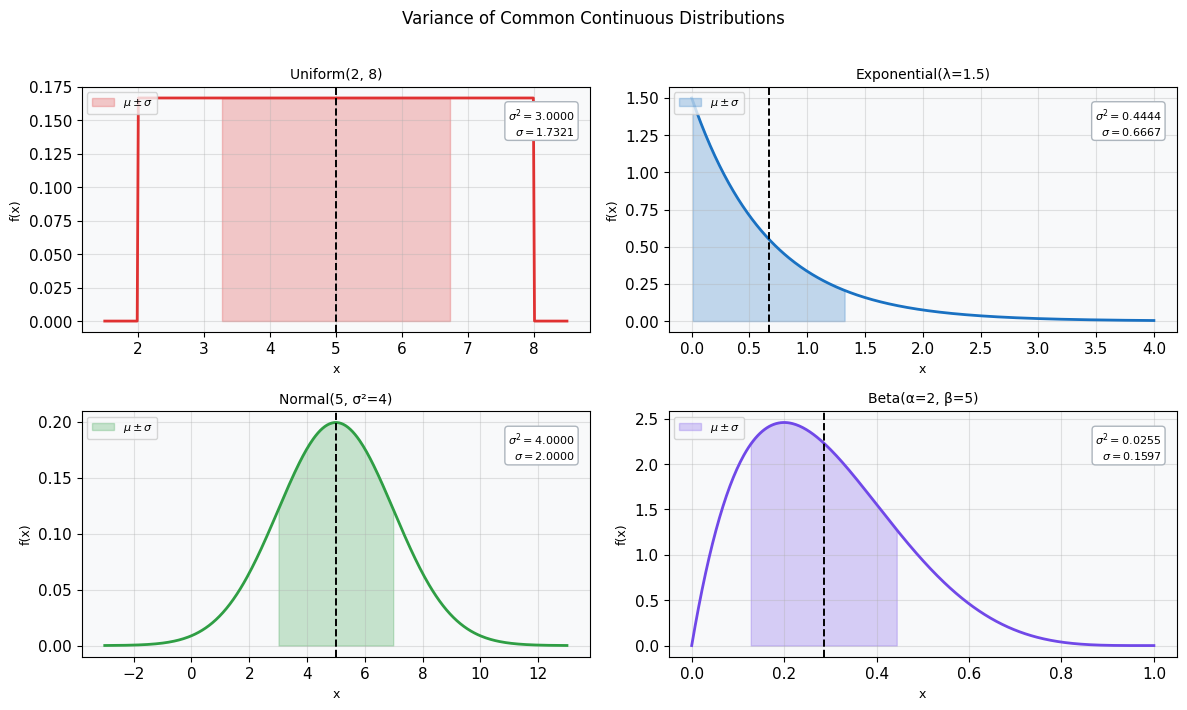

In [7]:
# Parameters
a_u, b_u   = 2.0, 8.0          # Uniform(2, 8)
lam        = 1.5                # Exponential(λ=1.5)
mu_n, sg_n = 5.0, 2.0          # Normal(5, 4)
al, be     = 2.0, 5.0          # Beta(2, 5)

dists = [
    {'dist': uniform(loc=a_u, scale=b_u-a_u),
     'x': np.linspace(a_u-0.5, b_u+0.5, 400),
     'title': f'Uniform({a_u:.0f}, {b_u:.0f})',
     'var_analytic': (b_u - a_u)**2 / 12,
     'color': '#e03131'},
    {'dist': expon(scale=1/lam),
     'x': np.linspace(0, 6/lam, 400),
     'title': f'Exponential(λ={lam})',
     'var_analytic': 1/lam**2,
     'color': '#1971c2'},
    {'dist': norm(loc=mu_n, scale=sg_n),
     'x': np.linspace(mu_n - 4*sg_n, mu_n + 4*sg_n, 400),
     'title': f'Normal({mu_n:.0f}, σ²={sg_n**2:.0f})',
     'var_analytic': sg_n**2,
     'color': '#2f9e44'},
    {'dist': beta(al, be),
     'x': np.linspace(0, 1, 400),
     'title': f'Beta(α={al:.0f}, β={be:.0f})',
     'var_analytic': (al*be) / ((al+be)**2 * (al+be+1)),
     'color': '#7048e8'},
]

lo_bounds = [a_u,    0,         mu_n-10*sg_n, 0]
hi_bounds = [b_u,    20/lam,    mu_n+10*sg_n, 1]

fig, axes = plt.subplots(2, 2, figsize=(12, 7))
print(f"{'Distribution':<28} {'E[X]':>8} {'Var(X) num':>12} {'Var(X) analytic':>16}")
print('─' * 68)

for ax, cfg, lo, hi in zip(axes.flat, dists, lo_bounds, hi_bounds):
    d = cfg['dist']
    x = cfg['x']
    y = d.pdf(x)
    mu_val, _ = quad(lambda t: t * d.pdf(t), lo, hi)
    var_num, _ = quad(lambda t: (t - mu_val)**2 * d.pdf(t), lo, hi)

    ax.plot(x, y, color=cfg['color'], lw=2)
    # ±σ shading
    sg_val = np.sqrt(var_num)
    mask = (x >= mu_val - sg_val) & (x <= mu_val + sg_val)
    ax.fill_between(x, 0, y, where=mask, color=cfg['color'], alpha=0.25,
                    label=r'$\mu \pm \sigma$')
    ax.axvline(mu_val, color='black', lw=1.4, ls='--')
    ax.set_title(cfg['title'], fontsize=10)
    ax.set_xlabel('x', fontsize=9)
    ax.set_ylabel('f(x)', fontsize=9)
    ax.text(0.97, 0.92,
            f'$\\sigma^2 = {var_num:.4f}$\n$\\sigma = {sg_val:.4f}$',
            transform=ax.transAxes, ha='right', va='top', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#adb5bd'))
    ax.legend(fontsize=8, loc='upper left')

    print(f"{cfg['title']:<28} {mu_val:>8.4f} {var_num:>12.6f} {cfg['var_analytic']:>16.6f}")

plt.suptitle('Variance of Common Continuous Distributions', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Summary

| Concept | Formula (Continuous RV) | Analogue (Discrete RV) |
|---|---|---|
| **Expectation** | $E[X] = \int x\, f(x)\,dx$ | $E[X] = \sum x_i\, P(x_i)$ |
| **Variance** | $\sigma^2 = \int(x-\mu)^2 f(x)\,dx$ | $\sigma^2 = \sum(x_i-\mu)^2 P(x_i)$ |
| **Alt formula** | $\sigma^2 = E[X^2] - \mu^2$ | $\sigma^2 = E[X^2] - \mu^2$ |
| **Std deviation** | $\sigma = \sqrt{\sigma^2}$ | $\sigma = \sqrt{\sigma^2}$ |
| **Moment order** | $E[X]$ = 1st order; $\sigma^2$ = 2nd order | same |

> The concept and formulas are identical for discrete and continuous RVs — summation (Σ) simply becomes integration (∫).